In [1]:
from pathlib import Path

import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse
from scipy.stats import median_abs_deviation
import numpy as np

# Set Base directory to the grandparent location of this script
BASE = Path('/mnt/hd1/home/ankitray/scFM/')

# Set working directory to the location of this script 
data_dir = BASE / 'data/scGPT_data'

# Print contents of the data directory for verification
print(f"Contents of data directory ({data_dir}):")
for item in data_dir.iterdir():
    print(item.name)

Contents of data directory (/mnt/hd1/home/ankitray/scFM/data/scGPT_data):
GSE212837.h5ad
GSE189600.h5ad
GSE174748.h5ad
GSE202379.h5ad
GSE192740.h5ad
GSE190487.h5ad
GSE185477.h5ad
GSE270488.h5ad
GSE159977.h5ad


In [2]:
# Read in each h5ad file with the Anndata object variable name being it's file name without the extension and store in dictionary
adata_dict = {}

for h5ad_file in data_dir.glob('*.h5ad'):
    adata_name = h5ad_file.stem  # Get file name without extension

    adata_dict[adata_name] = ad.read_h5ad(h5ad_file)  # Read h5ad file and store in dictionary
    print(adata_dict[adata_name])

AnnData object with n_obs × n_vars = 182302 × 33557
    obs: 'barcode', 'gsm_id', 'sample_desc', 'condition', 'donor', 'batch', 'sex', 'age', 'patient_id', 'assay_type', 'n_counts', 'n_genes', 'dataset', 'broad_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'typist_liver_predicted_labels', 'typist_liver_over_clustering', 'typist_liver_majority_voting', 'typist_liver_conf_score'
    var: 'gene_id', 'gene_symbol', 'feature_type', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'log1p', 'neighbors', 'over_clustering'
    obsm: 'X_pca'
    layers: 'counts', 'raw_counts'
    obsp: 'connectivities', 'distances'
AnnDat

## Check Datasets have correct variables/values

In [5]:
import numpy as np
import pandas as pd
from scipy import sparse
import gc
import re

def check_matrix_raw_counts_like(M, sample_n=5000, seed=0):
    """
    Heuristic check: raw counts should be non-negative and integer-like.
    This does not prove the matrix is raw counts, but flags likely problems.
    Works without densifying sparse matrices.
    """
    rng = np.random.default_rng(seed)

    if M is None:
        return {
            "present": False,
            "shape": None,
            "sparse": None,
            "nnz_or_sample_n": 0,
            "nonnegative": None,
            "integer_like": None,
            "min_sample": None,
            "max_sample": None,
            "raw_counts_likely": False,
        }

    is_sparse = sparse.issparse(M)
    shape = M.shape

    if is_sparse:
        vals = M.data
        if vals.size == 0:
            sampled = vals
        elif vals.size > sample_n:
            sampled = vals[rng.choice(vals.size, size=sample_n, replace=False)]
        else:
            sampled = vals

        if sampled.size == 0:
            nonnegative = True
            integer_like = True
            min_sample = 0
            max_sample = 0
        else:
            nonnegative = bool(np.nanmin(sampled) >= 0)
            integer_like = bool(np.allclose(sampled, np.round(sampled), atol=1e-6))
            min_sample = float(np.nanmin(sampled))
            max_sample = float(np.nanmax(sampled))

        nnz_or_sample_n = int(M.nnz)

    else:
        n_obs, n_vars = shape
        total_size = n_obs * n_vars
        n_to_sample = min(sample_n, total_size)

        rows = rng.integers(0, n_obs, size=n_to_sample)
        cols = rng.integers(0, n_vars, size=n_to_sample)

        sampled = np.asarray(M[rows, cols]).ravel()

        nonnegative = bool(np.nanmin(sampled) >= 0)
        integer_like = bool(np.allclose(sampled, np.round(sampled), atol=1e-6))
        min_sample = float(np.nanmin(sampled))
        max_sample = float(np.nanmax(sampled))
        nnz_or_sample_n = int(n_to_sample)

    return {
        "present": True,
        "shape": shape,
        "sparse": is_sparse,
        "nnz_or_sample_n": nnz_or_sample_n,
        "nonnegative": nonnegative,
        "integer_like": integer_like,
        "min_sample": min_sample,
        "max_sample": max_sample,
        "raw_counts_likely": bool(nonnegative and integer_like),
    }


def infer_var_name_type(var_names, n_check=1000):
    """
    Roughly infer whether var_names look like gene symbols or Ensembl IDs.
    """
    vals = pd.Index(var_names).astype(str)
    vals_sample = vals[:min(n_check, len(vals))]

    ensembl_like = vals_sample.str.match(r"^ENSG\d+", case=False).mean()
    symbol_like = vals_sample.str.match(r"^[A-Za-z][A-Za-z0-9\.\-]*$").mean()

    if ensembl_like > 0.7:
        guess = "Ensembl-like"
    elif symbol_like > 0.7:
        guess = "Gene-symbol-like"
    else:
        guess = "Mixed/unclear"

    return guess, float(ensembl_like), float(symbol_like)


def summarize_adata_requirements(adata_dict):
    rows = []

    for name, adata in adata_dict.items():
        x_check = check_matrix_raw_counts_like(adata.X)

        counts_present = "counts" in adata.layers
        counts_check = (
            check_matrix_raw_counts_like(adata.layers["counts"])
            if counts_present
            else check_matrix_raw_counts_like(None)
        )

        obs_cols = set(adata.obs.columns)
        var_cols = set(adata.var.columns)

        has_dataset = "dataset" in obs_cols
        has_patient_id = "patient_id" in obs_cols
        has_condition = "condition" in obs_cols
        has_broad_condition = "broad_condition" in obs_cols
        has_any_condition = has_condition or has_broad_condition
        has_cell_type = "typist_immune_majority_voting" in obs_cols or "typist_liver_majority_voting" in obs_cols

        var_guess, pct_ensembl_like, pct_symbol_like = infer_var_name_type(adata.var_names)

        possible_gene_symbol_cols = [
            col for col in adata.var.columns
            if col.lower() in ["gene_symbol", "gene_symbols", "symbol", "gene_name", "gene_names"]
        ]

        rows.append({
            "adata_name": name,
            "n_obs": adata.n_obs,
            "n_vars": adata.n_vars,

            "X_raw_counts_likely": x_check["raw_counts_likely"],
            "X_min_sample": x_check["min_sample"],
            "X_max_sample": x_check["max_sample"],

            "counts_layer_present": counts_present,
            "counts_layer_raw_counts_likely": counts_check["raw_counts_likely"],
            "counts_min_sample": counts_check["min_sample"],
            "counts_max_sample": counts_check["max_sample"],

            "has_dataset": has_dataset,
            "has_patient_id": has_patient_id,
            "has_condition": has_condition,
            "has_broad_condition": has_broad_condition,
            "has_condition_or_broad_condition": has_any_condition,
            "has_cell_type": has_cell_type,

            "var_names_unique": adata.var_names.is_unique,
            "var_names_type_guess": var_guess,
            "pct_ensembl_like_first_1000": pct_ensembl_like,
            "pct_symbol_like_first_1000": pct_symbol_like,
            "possible_gene_symbol_var_cols": ", ".join(possible_gene_symbol_cols) if possible_gene_symbol_cols else None,
            "var_names_example": ", ".join(map(str, adata.var_names[:5])),
        })

    summary = pd.DataFrame(rows)

    required_cols = [
        "X_raw_counts_likely",
        "counts_layer_raw_counts_likely",
        "has_dataset",
        "has_patient_id",
        "has_condition_or_broad_condition",
        "has_cell_type",
        "var_names_unique",
    ]

    summary["has_raw_counts_somewhere"] = (
        summary["X_raw_counts_likely"] | summary["counts_layer_raw_counts_likely"]
    )

    summary["passes_basic_requirements"] = (
        summary["has_raw_counts_somewhere"]
        & summary["has_dataset"]
        & summary["has_patient_id"]
        & summary["has_condition_or_broad_condition"]
        & summary["has_cell_type"]
        & summary["var_names_unique"]
        & summary["var_names_type_guess"].eq("Gene-symbol-like")
    )

    return summary


In [6]:
adata_check_summary = summarize_adata_requirements(adata_dict)

pd.set_option("display.max_columns", None)
display(adata_check_summary)

,adata_name,n_obs,n_vars,X_raw_counts_likely,X_min_sample,X_max_sample,counts_layer_present,counts_layer_raw_counts_likely,counts_min_sample,counts_max_sample,has_dataset,has_patient_id,has_condition,has_broad_condition,has_condition_or_broad_condition,has_cell_type,var_names_unique,var_names_type_guess,pct_ensembl_like_first_1000,pct_symbol_like_first_1000,possible_gene_symbol_var_cols,var_names_example,has_raw_counts_somewhere,passes_basic_requirements
0,GSE212837,182302,33557,False,0.540160,6.224429,True,True,1.0,333.000000,True,True,True,True,True,True,True,Gene-symbol-like,0.0,1.000,gene_symbol,"AL627309.1, AL627309.3, AL627309.5, AL627309.4...",True,True
1,GSE189600,55074,32277,False,0.594696,5.898077,True,True,1.0,121.000000,True,True,True,True,True,True,True,Gene-symbol-like,0.0,1.000,gene_symbols,"MIR1302-2HG, AL627309.1, AL627309.3, AL627309....",True,True
2,GSE174748,19038,27934,False,0.876029,6.692189,True,True,1.0,87.000000,True,True,True,True,True,True,True,Gene-symbol-like,0.0,1.000,None,"AL627309.1, AL627309.2, AC114498.1, AL669831.2...",True,True
3,GSE202379,64329,30596,False,0.460326,6.224256,True,True,1.0,753.000000,True,True,True,True,True,True,True,Gene-symbol-like,0.0,1.000,None,"AL627309.1, AL627309.5, LINC01409, LINC01128, ...",True,True
4,GSE192740,69758,30704,False,0.551551,6.496072,True,True,1.0,232.000000,True,True,True,True,True,True,True,Gene-symbol-like,0.0,0.999,None,"RP11-34P13.7, RP11-34P13.8, AL627309.1, RP11-3...",True,True
5,GSE190487,41995,19059,False,3.842932,6.496420,True,True,1.0,9.000000,True,True,True,True,True,True,True,Gene-symbol-like,0.0,1.000,gene_symbol,"AL627309.1, AL627309.3, AL669831.5, FAM87B, LI...",True,True
6,GSE185477,125790,37469,False,1.907650,6.234589,True,True,1.0,21.000000,True,True,True,True,True,True,True,Gene-symbol-like,0.0,1.000,gene_symbol,"A1BG, A1BG-AS1, A1CF, A2M, A2M-AS1",True,True
7,GSE270488,18376,21251,False,0.339564,5.653617,True,False,0.0,5.198035,True,True,True,True,True,True,True,Gene-symbol-like,0.0,1.000,None,"AL627309.1, AL627309.5, LINC01409, FAM87B, LIN...",False,False
8,GSE159977,103242,23993,False,0.506176,8.054668,True,True,1.0,508.000000,True,True,True,True,True,True,True,Gene-symbol-like,0.0,0.999,None,"RP11-34P13.7, RP11-34P13.8, RP11-34P13.9, FO53...",True,True


## Keep Only Immune and scRNA data

In [7]:
import gc

target_datasets = ["GSE270488", "GSE159977", "GSE190487", "GSE192740"]

# Keep any adata object whose dictionary key contains one of the target dataset IDs
selected_keys = [
    key for key in adata_dict.keys()
    if any(ds in key for ds in target_datasets)
]

print("Selected AnnData objects:")
for key in selected_keys:
    print(f"- {key}: {adata_dict[key].shape}")

print("\nDropping AnnData objects:")
for key in list(adata_dict.keys()):
    if key not in selected_keys:
        print(f"- {key}: {adata_dict[key].shape}")
        del adata_dict[key]

gc.collect()

print("\nRemaining AnnData objects:")
for key, adata in adata_dict.items():
    print(f"- {key}: {adata.shape}")

Selected AnnData objects:
- GSE192740: (69758, 30704)
- GSE190487: (41995, 19059)
- GSE270488: (18376, 21251)
- GSE159977: (103242, 23993)

Dropping AnnData objects:
- GSE212837: (182302, 33557)
- GSE189600: (55074, 32277)
- GSE174748: (19038, 27934)
- GSE202379: (64329, 30596)
- GSE185477: (125790, 37469)

Remaining AnnData objects:
- GSE192740: (69758, 30704)
- GSE190487: (41995, 19059)
- GSE270488: (18376, 21251)
- GSE159977: (103242, 23993)


In [8]:
for key in list(adata_dict.keys()):
    adata = adata_dict[key]

    print("=" * 80)
    print(f"Processing {key}")
    print(f"Before filtering: {adata.shape}")

    if "assay_type" not in adata.obs.columns:
        print("WARNING: adata.obs['assay_type'] not found. Leaving this object unchanged.")
        continue

    print("assay_type counts before:")
    print(adata.obs["assay_type"].value_counts(dropna=False))

    keep_mask = adata.obs["assay_type"].astype(str).ne("snRNA-seq")

    adata_dict[key] = adata[keep_mask].copy()

    print(f"After removing assay_type == 'snRNA-seq': {adata_dict[key].shape}")
    print("assay_type counts after:")
    print(adata_dict[key].obs["assay_type"].value_counts(dropna=False))

    # Free memory from old object/view references
    del adata
    gc.collect()

Processing GSE192740
Before filtering: (69758, 30704)
assay_type counts before:
assay_type
snRNA-seq    39020
scRNA-seq    30738
Name: count, dtype: int64
After removing assay_type == 'snRNA-seq': (30738, 30704)
assay_type counts after:
assay_type
scRNA-seq    30738
Name: count, dtype: int64
Processing GSE190487
Before filtering: (41995, 19059)
assay_type counts before:
assay_type
scRNA-seq    41995
Name: count, dtype: int64
After removing assay_type == 'snRNA-seq': (41995, 19059)
assay_type counts after:
assay_type
scRNA-seq    41995
Name: count, dtype: int64
Processing GSE270488
Before filtering: (18376, 21251)
assay_type counts before:
assay_type
scRNA-seq    18376
Name: count, dtype: int64
After removing assay_type == 'snRNA-seq': (18376, 21251)
assay_type counts after:
assay_type
scRNA-seq    18376
Name: count, dtype: int64
Processing GSE159977
Before filtering: (103242, 23993)
assay_type counts before:
assay_type
scRNA-seq    103242
Name: count, dtype: int64
After removing assay_

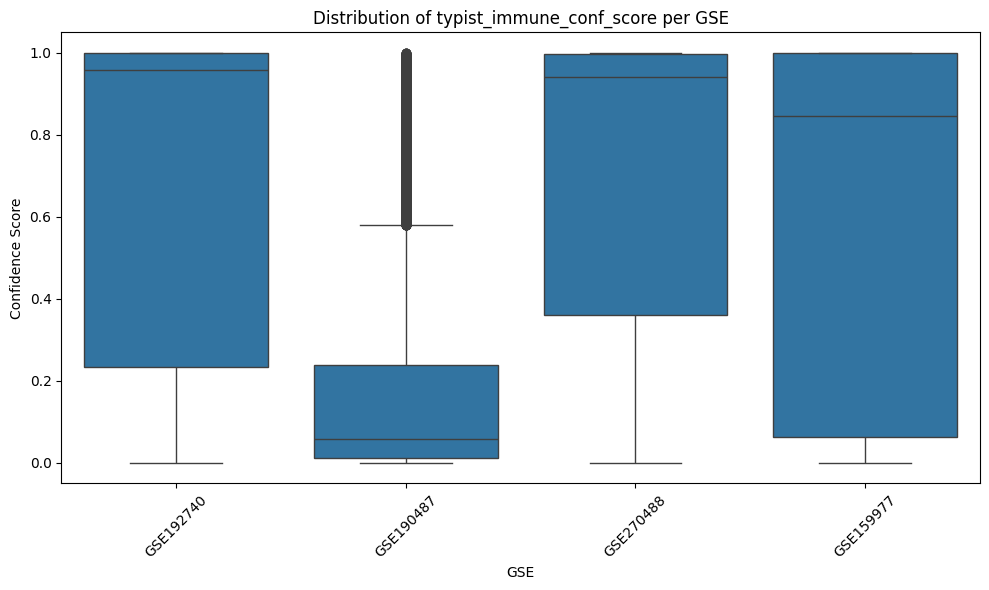

In [11]:
# Boxplot for immune GSEs - typist_immune_conf_score
import seaborn as sns
from matplotlib import pyplot as plt

# Prepare data for boxplot
immune_conf_data = []
for gse_name in adata_dict:
    adata = adata_dict[gse_name]
    if "typist_immune_conf_score" in adata.obs.columns:
        conf_scores = adata.obs["typist_immune_conf_score"].copy()
        conf_scores_df = pd.DataFrame({
            'GSE': gse_name,
            'conf_score': conf_scores
        })
        immune_conf_data.append(conf_scores_df)

if immune_conf_data:
    immune_conf_df = pd.concat(immune_conf_data, ignore_index=True)
    # Create boxplot
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(data=immune_conf_df, x='GSE', y='conf_score', ax=ax)
    ax.set_title('Distribution of typist_immune_conf_score per GSE')
    ax.set_xlabel('GSE')
    ax.set_ylabel('Confidence Score')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [12]:
print("Final objects after dataset selection and snRNA-seq removal:")

for key, adata in adata_dict.items():
    print("=" * 80)
    print(key)    
    if "assay_type" in adata.obs.columns:
        print(adata.obs["assay_type"].value_counts(dropna=False))
    else:
        print("No assay_type column")

Final objects after dataset selection and snRNA-seq removal:
GSE192740
assay_type
scRNA-seq    30738
Name: count, dtype: int64
GSE190487
assay_type
scRNA-seq    41995
Name: count, dtype: int64
GSE270488
assay_type
scRNA-seq    18376
Name: count, dtype: int64
GSE159977
assay_type
scRNA-seq    103242
Name: count, dtype: int64


In [13]:
# 194 351 cells total before filtering for confidence
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

score_col = "typist_immune_conf_score"

# Choose thresholds from 50% to 100%
# Change step to 0.01 if you want finer thresholds
thresholds = np.round(np.arange(0.50, 1.001, 0.05), 2)

# Collect confidence scores from all adata objects
rows = []

for gse_name, adata in adata_dict.items():
    if score_col not in adata.obs.columns:
        print(f"WARNING: {gse_name} does not have {score_col}. Skipping.")
        continue

    scores = pd.to_numeric(adata.obs[score_col], errors="coerce")

    temp = pd.DataFrame({
        "GSE": gse_name,
        "conf_score": scores.values
    })

    rows.append(temp)

immune_conf_df = pd.concat(rows, ignore_index=True)

print(f"Total cells across included objects: {immune_conf_df.shape[0]:,}")
print(f"Cells with non-missing {score_col}: {immune_conf_df['conf_score'].notna().sum():,}")
print(f"Cells with missing {score_col}: {immune_conf_df['conf_score'].isna().sum():,}")

# Overall threshold impact
overall_threshold_summary = []

total_cells = immune_conf_df.shape[0]

for thresh in thresholds:
    kept = (immune_conf_df["conf_score"] >= thresh).sum()
    removed = total_cells - kept

    overall_threshold_summary.append({
        "threshold": thresh,
        "cells_kept": kept,
        "cells_removed": removed,
        "percent_kept": kept / total_cells * 100,
        "percent_removed": removed / total_cells * 100
    })

overall_threshold_summary = pd.DataFrame(overall_threshold_summary)

display(overall_threshold_summary)

Total cells across included objects: 194,351
Cells with non-missing typist_immune_conf_score: 194,351
Cells with missing typist_immune_conf_score: 0


,threshold,cells_kept,cells_removed,percent_kept,percent_removed
0,0.50,100039,94312,51.473365,48.526635
1,0.55,97699,96652,50.269358,49.730642
2,0.60,95294,99057,49.031906,50.968094
3,0.65,92826,101525,47.762039,52.237961
4,0.70,90413,103938,46.520471,53.479529
5,0.75,87840,106511,45.196577,54.803423
6,0.80,84898,109453,43.682821,56.317179
7,0.85,81535,112816,41.952447,58.047553
8,0.90,77218,117133,39.731208,60.268792
9,0.95,70557,123794,36.303904,63.696096


In [14]:
import gc
import pandas as pd

score_col = "typist_immune_conf_score"
threshold = 0.75

filter_summary = []

for gse_name in list(adata_dict.keys()):
    adata = adata_dict[gse_name]

    print("=" * 80)
    print(f"Processing: {gse_name}")
    print(f"Before filtering: {adata.shape}")

    if score_col not in adata.obs.columns:
        print(f"WARNING: {score_col} not found. Leaving {gse_name} unchanged.")
        filter_summary.append({
            "GSE": gse_name,
            "before_cells": adata.n_obs,
            "after_cells": adata.n_obs,
            "removed_cells": 0,
            "percent_kept": 100.0,
            "status": f"Skipped: missing {score_col}"
        })
        continue

    scores = pd.to_numeric(adata.obs[score_col], errors="coerce")
    keep_mask = scores >= threshold

    before_n = adata.n_obs
    after_n = int(keep_mask.sum())
    removed_n = before_n - after_n

    adata_dict[gse_name] = adata[keep_mask.values].copy()

    print(f"After filtering: {adata_dict[gse_name].shape}")
    print(f"Removed cells: {removed_n:,}")
    print(f"Kept cells: {after_n:,} ({after_n / before_n * 100:.2f}%)")

    filter_summary.append({
        "GSE": gse_name,
        "before_cells": before_n,
        "after_cells": after_n,
        "removed_cells": removed_n,
        "percent_kept": after_n / before_n * 100,
        "status": "Filtered"
    })

    del adata
    gc.collect()

filter_summary = pd.DataFrame(filter_summary)
display(filter_summary)

print("=" * 80)
print(f"Total cells before: {filter_summary['before_cells'].sum():,}")
print(f"Total cells after: {filter_summary['after_cells'].sum():,}")
print(f"Total cells removed: {filter_summary['removed_cells'].sum():,}")
print(f"Overall percent kept: {filter_summary['after_cells'].sum() / filter_summary['before_cells'].sum() * 100:.2f}%")

Processing: GSE192740
Before filtering: (30738, 30704)
After filtering: (19366, 30704)
Removed cells: 11,372
Kept cells: 19,366 (63.00%)
Processing: GSE190487
Before filtering: (41995, 19059)
After filtering: (2179, 19059)
Removed cells: 39,816
Kept cells: 2,179 (5.19%)
Processing: GSE270488
Before filtering: (18376, 21251)
After filtering: (11651, 21251)
Removed cells: 6,725
Kept cells: 11,651 (63.40%)
Processing: GSE159977
Before filtering: (103242, 23993)
After filtering: (54644, 23993)
Removed cells: 48,598
Kept cells: 54,644 (52.93%)


,GSE,before_cells,after_cells,removed_cells,percent_kept,status
0,GSE192740,30738,19366,11372,63.003449,Filtered
1,GSE190487,41995,2179,39816,5.188713,Filtered
2,GSE270488,18376,11651,6725,63.403352,Filtered
3,GSE159977,103242,54644,48598,52.928072,Filtered


Total cells before: 194,351
Total cells after: 87,840
Total cells removed: 106,511
Overall percent kept: 45.20%


In [16]:
import pandas as pd

cols_to_summarize = [
    "typist_immune_majority_voting",
    "broad_condition",
    "patient_id"
]

for gse_name, adata in adata_dict.items():
    print("=" * 100)
    print(f"{gse_name}")
    print(f"Total cells: {adata.n_obs:,}")

    for col in cols_to_summarize:
        print("-" * 100)
        print(f"Counts for adata.obs['{col}']")

        if col not in adata.obs.columns:
            print(f"WARNING: {col} not found in {gse_name}")
            continue

        counts = (
            adata.obs[col]
            .astype("string")
            .fillna("NA")
            .value_counts(dropna=False)
            .rename_axis(col)
            .reset_index(name="n_cells")
        )

        counts["percent"] = counts["n_cells"] / adata.n_obs * 100

        display(counts)

GSE192740
Total cells: 19,366
----------------------------------------------------------------------------------------------------
Counts for adata.obs['typist_immune_majority_voting']


,typist_immune_majority_voting,n_cells,percent
0,MAIT cells,4211,21.744294
1,Tem/Trm cytotoxic T cells,3177,16.40504
2,CD16- NK cells,2447,12.635547
3,CD16+ NK cells,2380,12.28958
4,Endothelial cells,1723,8.897036
5,Tem/Temra cytotoxic T cells,1277,6.594031
6,Kupffer cells,1221,6.304864
7,Classical monocytes,991,5.117216
8,Non-classical monocytes,379,1.957038
9,Macrophages,264,1.363214


----------------------------------------------------------------------------------------------------
Counts for adata.obs['broad_condition']


,broad_condition,n_cells,percent
0,MASLD,14413,74.424249
1,Healthy,4953,25.575751


----------------------------------------------------------------------------------------------------
Counts for adata.obs['patient_id']


...

,typist_immune_majority_voting,n_cells,percent
0,CD16- NK cells,16152,29.558597
1,CD16+ NK cells,10245,18.748627
2,Tem/Trm cytotoxic T cells,6873,12.577776
3,MAIT cells,4951,9.060464
4,Tem/Effector helper T cells,3613,6.611888
5,Tem/Temra cytotoxic T cells,3131,5.729815
6,Naive B cells,2396,4.384745
7,Non-classical monocytes,1268,2.320474
8,Tcm/Naive helper T cells,1018,1.862968
9,Classical monocytes,823,1.506112


----------------------------------------------------------------------------------------------------
Counts for adata.obs['broad_condition']


,broad_condition,n_cells,percent
0,MASH,33394,61.111924
1,Healthy,21250,38.888076


----------------------------------------------------------------------------------------------------
Counts for adata.obs['patient_id']


,patient_id,n_cells,percent
0,PT-8,9798,17.930605
1,PT-19,6941,12.702218
2,PT-17,6096,11.155845
3,PT-5,5633,10.308543
4,PT-11,5563,10.180441
5,PT-16,5489,10.045019
6,PT-9,5160,9.44294
7,PT-20,5005,9.159286
8,PT-12,4660,8.527926
9,PT-21,299,0.547178


In [17]:
combined_obs = []

for gse_name, adata in adata_dict.items():
    available_cols = [col for col in cols_to_summarize if col in adata.obs.columns]

    temp = adata.obs[available_cols].copy()
    temp["GSE"] = gse_name
    combined_obs.append(temp)

combined_obs = pd.concat(combined_obs, axis=0, ignore_index=True)

for col in cols_to_summarize:
    print("=" * 100)
    print(f"Combined counts for '{col}' across all adata objects")

    if col not in combined_obs.columns:
        print(f"WARNING: {col} not found in combined_obs")
        continue

    counts = (
        combined_obs[col]
        .astype("string")
        .fillna("NA")
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="n_cells")
    )

    counts["percent"] = counts["n_cells"] / len(combined_obs) * 100

    display(counts)

Combined counts for 'typist_immune_majority_voting' across all adata objects


,typist_immune_majority_voting,n_cells,percent
0,CD16- NK cells,18801,21.403689
1,Tem/Trm cytotoxic T cells,15932,18.137523
2,CD16+ NK cells,12625,14.372723
3,MAIT cells,9571,10.895947
4,Tem/Temra cytotoxic T cells,5310,6.045082
5,Tem/Effector helper T cells,5012,5.705829
6,CRTAM+ gamma-delta T cells,2947,3.354964
7,Memory B cells,2736,3.114754
8,Naive B cells,2396,2.727687
9,Classical monocytes,1814,2.065118


Combined counts for 'broad_condition' across all adata objects


,broad_condition,n_cells,percent
0,MASH,41069,46.754326
1,Healthy,30179,34.356785
2,MASLD,16592,18.888889


Combined counts for 'patient_id' across all adata objects


,patient_id,n_cells,percent
0,PT-8,9798,11.154372
1,PT-19,6941,7.901867
2,H23,6238,7.101548
3,PT-17,6096,6.939891
4,PT-5,5633,6.412796
5,PT-11,5563,6.333106
6,PT-16,5489,6.248862
7,PT-9,5160,5.874317
8,PT-20,5005,5.69786
9,H25,4809,5.474727


In [18]:
import pandas as pd

required_cols = [
    "typist_immune_majority_voting",
    "broad_condition",
    "patient_id"
]

# Combine obs metadata from all remaining adata objects
combined_obs = []

for gse_name, adata in adata_dict.items():
    missing_cols = [col for col in required_cols if col not in adata.obs.columns]

    if missing_cols:
        print(f"WARNING: {gse_name} is missing columns: {missing_cols}. Skipping this object.")
        continue

    temp = adata.obs[required_cols].copy()
    temp["GSE"] = gse_name
    combined_obs.append(temp)

combined_obs = pd.concat(combined_obs, axis=0, ignore_index=True)

# Clean columns for counting
combined_obs["typist_immune_majority_voting"] = (
    combined_obs["typist_immune_majority_voting"]
    .astype("string")
    .fillna("NA")
)

combined_obs["broad_condition"] = (
    combined_obs["broad_condition"]
    .astype("string")
    .fillna("NA")
)

combined_obs["patient_id"] = (
    combined_obs["patient_id"]
    .astype("string")
    .fillna("NA")
)

# Summary:
# For each CellTypist immune label + broad_condition:
# - number of cells
# - number of unique patients
summary_by_celltype_condition = (
    combined_obs
    .groupby(["typist_immune_majority_voting", "broad_condition"])
    .agg(
        n_cells=("patient_id", "size"),
        n_unique_patients=("patient_id", "nunique")
    )
    .reset_index()
    .sort_values(
        ["typist_immune_majority_voting", "broad_condition"],
        ascending=[True, True]
    )
)

display(summary_by_celltype_condition)

,typist_immune_majority_voting,broad_condition,n_cells,n_unique_patients
0,B cells,Healthy,27,2
1,B cells,MASLD,73,4
2,CD16+ NK cells,Healthy,4542,6
3,CD16+ NK cells,MASH,6224,6
4,CD16+ NK cells,MASLD,1859,4
...,...,...,...,...
69,Trm cytotoxic T cells,Healthy,146,4
70,Trm cytotoxic T cells,MASH,150,7
71,pDC,Healthy,111,5
72,pDC,MASH,271,5


In [19]:
# Cell counts per broad_condition
cell_count_pivot = summary_by_celltype_condition.pivot_table(
    index="typist_immune_majority_voting",
    columns="broad_condition",
    values="n_cells",
    fill_value=0
)

# Unique patient counts per broad_condition
patient_count_pivot = summary_by_celltype_condition.pivot_table(
    index="typist_immune_majority_voting",
    columns="broad_condition",
    values="n_unique_patients",
    fill_value=0
)

print("Cell counts per broad_condition:")
display(cell_count_pivot)

print("Unique patient counts per broad_condition:")
display(patient_count_pivot)

Cell counts per broad_condition:


broad_condition,Healthy,MASH,MASLD
typist_immune_majority_voting,,,
B cells,27.0,0.0,73.0
CD16+ NK cells,4542.0,6224.0,1859.0
CD16- NK cells,7252.0,9806.0,1743.0
CRTAM+ gamma-delta T cells,1510.0,1437.0,0.0
Classical monocytes,652.0,430.0,732.0
DC1,59.0,73.0,72.0
DC2,119.0,201.0,62.0
Endothelial cells,297.0,0.0,1426.0
Erythrophagocytic macrophages,17.0,5.0,69.0


Unique patient counts per broad_condition:


broad_condition,Healthy,MASH,MASLD
typist_immune_majority_voting,,,
B cells,2.0,0.0,4.0
CD16+ NK cells,6.0,6.0,4.0
CD16- NK cells,7.0,8.0,4.0
CRTAM+ gamma-delta T cells,6.0,7.0,0.0
Classical monocytes,6.0,6.0,4.0
DC1,6.0,6.0,4.0
DC2,6.0,5.0,3.0
Endothelial cells,1.0,0.0,4.0
Erythrophagocytic macrophages,4.0,2.0,4.0


In [20]:
min_cells = 500
min_patients_total = 3

eligible_cell_types = []

for cell_type in cell_count_pivot.index:
    healthy_cells = cell_count_pivot.loc[cell_type, "Healthy"] if "Healthy" in cell_count_pivot.columns else 0
    mash_cells = cell_count_pivot.loc[cell_type, "MASH"] if "MASH" in cell_count_pivot.columns else 0

    healthy_patients = patient_count_pivot.loc[cell_type, "Healthy"] if "Healthy" in patient_count_pivot.columns else 0
    mash_patients = patient_count_pivot.loc[cell_type, "MASH"] if "MASH" in patient_count_pivot.columns else 0

    total_patients = healthy_patients + mash_patients

    if (
        healthy_cells > min_cells
        and mash_cells > min_cells
        and total_patients > min_patients_total
    ):
        eligible_cell_types.append({
            "cell_type": cell_type,
            "Healthy_cells": healthy_cells,
            "MASH_cells": mash_cells,
            "Healthy_patients": healthy_patients,
            "MASH_patients": mash_patients,
            "total_patient_condition_counts": total_patients
        })

eligible_cell_types_df = pd.DataFrame(eligible_cell_types)

eligible_cell_types_df = eligible_cell_types_df.sort_values(
    ["Healthy_cells", "MASH_cells"],
    ascending=False
)

display(eligible_cell_types_df)

,cell_type,Healthy_cells,MASH_cells,Healthy_patients,MASH_patients,total_patient_condition_counts
1,CD16- NK cells,7252.0,9806.0,7.0,8.0,15.0
8,Tem/Trm cytotoxic T cells,4608.0,8747.0,8.0,8.0,16.0
0,CD16+ NK cells,4542.0,6224.0,6.0,6.0,12.0
3,MAIT cells,3936.0,3313.0,8.0,8.0,16.0
7,Tem/Temra cytotoxic T cells,1919.0,2338.0,8.0,7.0,15.0
6,Tem/Effector helper T cells,1826.0,2965.0,8.0,8.0,16.0
2,CRTAM+ gamma-delta T cells,1510.0,1437.0,6.0,7.0,13.0
4,Naive B cells,1099.0,1297.0,4.0,6.0,10.0
5,Non-classical monocytes,745.0,557.0,6.0,6.0,12.0


In [23]:
eligible_cell_types = list(eligible_cell_types_df["cell_type"])
eligible_cell_types

['CD16- NK cells',
 'Tem/Trm cytotoxic T cells',
 'CD16+ NK cells',
 'MAIT cells',
 'Tem/Temra cytotoxic T cells',
 'Tem/Effector helper T cells',
 'CRTAM+ gamma-delta T cells',
 'Naive B cells',
 'Non-classical monocytes']

In [25]:
import anndata as ad
import gc
from pathlib import Path

out_path = data_dir / "scgpt_merged_may_6_26.h5ad"

# Prepare objects
adatas_to_merge = {}

for name, adata in adata_dict.items():
    print("=" * 80)
    print(f"Preparing {name}: {adata.shape}")

    # Make var_names unique if needed
    if not adata.var_names.is_unique:
        print(f"WARNING: {name} has non-unique var_names. Making unique.")
        adata.var_names_make_unique()

    # Add source label manually too
    adata.obs["source_adata"] = name

    adatas_to_merge[name] = adata

# Outer-join concatenate all AnnData objects
# Since adatas_to_merge is a dictionary, do NOT pass keys=
adata_merged = ad.concat(
    adatas_to_merge,
    axis=0,
    join="outer",
    label="merge_key",
    index_unique="__",
    fill_value=0,
    merge="first"
)

print("=" * 80)
print("Merged AnnData:")
print(adata_merged)
print(f"n_obs: {adata_merged.n_obs:,}")
print(f"n_vars: {adata_merged.n_vars:,}")

print("\nobs columns:")
print(adata_merged.obs.columns.tolist())

print("\nExample var names:")
print(adata_merged.var_names[:10].tolist())

print("\nLayers:")
print(list(adata_merged.layers.keys()))

# Save
adata_merged.write_h5ad(out_path, compression="gzip")

print("=" * 80)
print(f"Saved merged AnnData to: {out_path}")

Preparing GSE192740: (19366, 30704)
Preparing GSE190487: (2179, 19059)
Preparing GSE270488: (11651, 21251)
Preparing GSE159977: (54644, 23993)
Merged AnnData:
AnnData object with n_obs × n_vars = 87840 × 39814
    obs: 'sample name', 'source name', 'organism', 'characteristics: shortfilename', 'characteristics: strain', 'characteristics: platform', 'characteristics: digestion method', 'characteristics: number of added abs', 'characteristics: number of cells', 'molecule', 'description', 'sample_class', 'assay_type', 'shortfilename', 'sample_group', 'patient_id', 'biopsy_used_for ', 'sex', 'age', 'weight_kg', 'height_cm', 'reason_for_hospitalization', 'procedure', 'concomitant_medication', 'concomitant_disorders_operations', 'alcohol_intake', 'steatosis', 'fibrosis', 'cardiometabolic_func_needed', 'condition', 'bmi', 'gsm_id', 'alcohol_use', 'dataset', 'n_counts', 'n_genes', 'broad_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_coun

TypeError: Can't implicitly convert non-string objects to strings

In [26]:
import pandas as pd
import numpy as np
from pathlib import Path

out_path = data_dir / "scgpt_merged_may_6_26.h5ad"

# -----------------------------
# 1. Inspect problematic obs columns
# -----------------------------
print("Object-like obs columns:")
object_cols = adata_merged.obs.select_dtypes(include=["object"]).columns.tolist()
print(object_cols)

for col in object_cols:
    types_present = adata_merged.obs[col].map(lambda x: type(x).__name__).value_counts(dropna=False)
    print("=" * 80)
    print(col)
    print(types_present.head(10))


# -----------------------------
# 2. Fix known numeric columns
# -----------------------------
# Add other numeric clinical columns here if needed
numeric_like_cols = [
    "bmi",
    "age",
    "fibrosis_stage",
    "nas_score",
    "ballooning",
    "steatosis",
    "inflammation",
    "n_counts",
    "n_genes", 
    "characteristics: number of added abs",
    "characteristics: number of cells", 
    "weight_kg",
    "height_cm"
]

for col in numeric_like_cols:
    if col in adata_merged.obs.columns:
        print(f"Converting obs['{col}'] to numeric float64")
        adata_merged.obs[col] = pd.to_numeric(
            adata_merged.obs[col],
            errors="coerce"
        ).astype("float64")


# -----------------------------
# 3. Convert remaining object columns to clean strings
# -----------------------------
for col in adata_merged.obs.columns:
    if adata_merged.obs[col].dtype == "object":
        print(f"Converting obs['{col}'] to string")
        adata_merged.obs[col] = (
            adata_merged.obs[col]
            .astype("string")
            .fillna("NA")
            .astype(str)
        )

for col in adata_merged.var.columns:
    if adata_merged.var[col].dtype == "object":
        print(f"Converting var['{col}'] to string")
        adata_merged.var[col] = (
            adata_merged.var[col]
            .astype("string")
            .fillna("NA")
            .astype(str)
        )


# -----------------------------
# 4. Ensure obs/var index names are safe
# -----------------------------
adata_merged.obs_names = adata_merged.obs_names.astype(str)
adata_merged.var_names = adata_merged.var_names.astype(str)

adata_merged.obs_names_make_unique()
adata_merged.var_names_make_unique()


# -----------------------------
# 5. Optional: convert repeated strings to categoricals
# -----------------------------
adata_merged.strings_to_categoricals()


# -----------------------------
# 6. Save h5ad
# -----------------------------
adata_merged.write_h5ad(out_path, compression="gzip")

print("=" * 80)
print(f"Saved merged AnnData to: {out_path}")
print(adata_merged)

Object-like obs columns:
['bmi']
bmi
bmi
float    68474
str      19366
Name: count, dtype: int64
Converting obs['bmi'] to numeric float64
Converting obs['age'] to numeric float64
Converting obs['steatosis'] to numeric float64
Converting obs['n_counts'] to numeric float64
Converting obs['n_genes'] to numeric float64
Converting obs['characteristics: number of added abs'] to numeric float64
Converting obs['characteristics: number of cells'] to numeric float64
Converting obs['weight_kg'] to numeric float64
Converting obs['height_cm'] to numeric float64
Converting var['mt'] to string
Converting var['ribo'] to string
Converting var['hb'] to string
Saved merged AnnData to: /mnt/hd1/home/ankitray/scFM/data/scGPT_data/scgpt_merged_may_6_26.h5ad
AnnData object with n_obs × n_vars = 87840 × 39814
    obs: 'sample name', 'source name', 'organism', 'characteristics: shortfilename', 'characteristics: strain', 'characteristics: platform', 'characteristics: digestion method', 'characteristics: number 